In [8]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

In [9]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/illegal-dumping-nov12-2025/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from datetime import datetime
from shapely.geometry import Polygon
from shapely.geometry import Point, MultiPoint

np.random.seed(999)

import importlib
importlib.reload(bstpp)

from bstpp.main import Hawkes_Model
#from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution
from bstpp.trigger import Temporal_Power_Law

#from bstpp.cox_hawkes_latent import Cox_Hawkes_Latent, prepare_litter_and_reporting_args

from bstpp.cox_hawkes_shared import Cox_Hawkes_Shared, attach_litter_survey_args, attach_dumping_report_args, plot_dumping_report_regression


JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [10]:
## Gateway location
fence_point = "40.021707, -75.112372"
fence_point2 = "40.022489, -75.111869"
fence_point3 = "40.023520, -75.112041"
fence_point4 = "40.022518, -75.112038"
fence_point5 = "40.026709, -75.114394"
fence_point6 = "40.026388, -75.112939"
fence_point7 = "40.026045, -75.114667"
fence_point8 = "40.022313, -75.114887"
fence_point9 = "40.021759, -75.112816"
fence_point10 = "40.023762, -75.110918"

# helper: "lat, lon" -> (lon, lat)
def to_lonlat(pt):
    lat, lon = map(float, pt.split(","))
    return (lon, lat)

# collect all points (add/remove as needed)
pts_str = [
    fence_point, fence_point2, fence_point3, fence_point4, fence_point5,
    fence_point6, fence_point7, fence_point8, fence_point9, fence_point10
]

points = [Point(to_lonlat(s)) for s in pts_str]

# outer boundary that encloses all points
fence_plg = gpd.GeoSeries([MultiPoint(points).convex_hull], crs="EPSG:4326")

# project to meters CRS for buffering/area
fence_plg_26918 = fence_plg.to_crs("EPSG:26918")

# save as gdf
fence_plg_gdf = gpd.GeoDataFrame(
    geometry=fence_plg_26918,
    crs="EPSG:26918"
)


In [11]:
# crop fence polygon to tacony park boundary
all_parks = gpd.read_file("output/all_parks_gdf.geojson")
tacony_park = all_parks[all_parks['PARENT_NAME'] == "Tacony Creek Park"]

# 1) dissolve park into one geometry
park_geom = tacony_park.unary_union

# 2) clip / adjust fence polygon to park boundary
fence_plg_gdf["geometry"] = fence_plg_gdf.geometry.intersection(park_geom)

# 3) drop empty results (if any)
fence_plg_gdf = fence_plg_gdf[~fence_plg_gdf.is_empty & fence_plg_gdf.geometry.notna()].copy()

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_60777/4169602072.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  park_geom = tacony_park.unary_union


In [12]:
# set buffer zone
fence_buffer = fence_plg_gdf.buffer(150)

# save as gdf 
fence_buffer_gdf = gpd.GeoDataFrame(
    geometry=fence_buffer,
    crs="EPSG:26918"
)

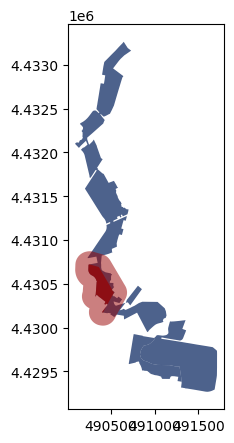

In [13]:
## plotting
# import park boundary
all_parks = gpd.read_file("output/all_parks_gdf.geojson")
# filter to tacony park
tacony_park = all_parks[all_parks['PARENT_NAME'] == "Tacony Creek Park"]

fig, ax = plt.subplots(figsize=(3, 5))
tacony_park.plot(ax=ax, color='#011f5b', alpha=0.7)
fence_plg_gdf.plot(ax=ax, color='#990000', alpha=0.7)
fence_buffer_gdf.plot(ax=ax, color='#990000', alpha=0.5)

plt.show()

In [14]:
## import other year's report
## load 2024 data
litter_24 = gpd.read_file('data/311/2024/public_cases_fc.shp')
## filter data
illegal_dumping_24 = litter_24[litter_24['service_na'] == "Illegal Dumping"]

## load 2023 data
litter_23 = gpd.read_file('data/311/2023/public_cases_fc.shp')
## filter data
illegal_dumping_23 = litter_23[litter_23['service_na'] == "Illegal Dumping"]

## load 2022 data
litter_22 = gpd.read_file('data/311/2022/public_cases_fc.shp')
## filter data
illegal_dumping_22 = litter_22[litter_22['service_na'] == "Illegal Dumping"]

## load 2021 data
litter_21 = gpd.read_file('data/311/2021/public_cases_fc.shp')
## filter data
illegal_dumping_21 = litter_21[litter_21['service_na'] == "Illegal Dumping"]

## load 2020 data: skip since COVID
litter_25 = gpd.read_file('data/311/2025/public_cases_fc.shp')
# filter data
illegal_dumping_25 = litter_25[litter_25['service_na'] == "Illegal Dumping"]

In [15]:
illegal_dumping_21 = illegal_dumping_21.to_crs(epsg=26918)
illegal_dumping_22 = illegal_dumping_22.to_crs(epsg=26918)
illegal_dumping_23 = illegal_dumping_23.to_crs(epsg=26918)
illegal_dumping_24 = illegal_dumping_24.to_crs(epsg=26918)
illegal_dumping_25 = illegal_dumping_25.to_crs(epsg=26918)

## concact 2021, 2022, 2023, 2024, and 2025 data
illegal_dumping = pd.concat([
    illegal_dumping_25,
    illegal_dumping_21,
    illegal_dumping_22,
    illegal_dumping_23,
    illegal_dumping_24
])
total_days = 365*5

In [16]:
# filter out cases that are in the fence buffer
df = illegal_dumping.sjoin(fence_buffer_gdf, predicate='within')
df = df.drop(columns=['index_right'])
df.shape

(255, 19)

In [17]:
# define colors
blue_family = {
    2021: "#01112f",  # darkest
    2022: "#012a6b",
    2023: "#01408f",
    2024: "#025bb5",  # lightest
}

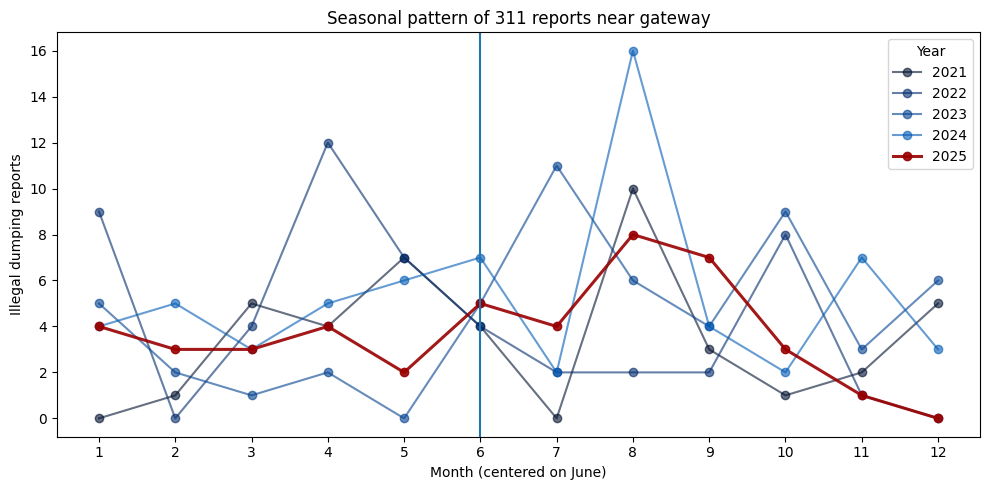

In [18]:
# ensure datetime
df["requested_"] = pd.to_datetime(
    df["requested_"], errors="coerce"
)

df = df.dropna(subset=["requested_"]).copy()

df["year"] = df["requested_"].dt.year
df["month"] = df["requested_"].dt.month

# bin by year and month
monthly_counts = (
    df.groupby(["year", "month"])
      .size()
      .reset_index(name="count")
)

# force to show all 12 months
years = sorted(monthly_counts["year"].unique())
all_year_month = pd.MultiIndex.from_product(
    [years, range(1, 13)],
    names=["year", "month"]
)

monthly_counts = (
    monthly_counts
      .set_index(["year", "month"])
      .reindex(all_year_month, fill_value=0)   # <-- missing months become 0
      .reset_index()
)

# center month on June
monthly_counts["month_centered"] = monthly_counts["month"] - 6

#plot
fig, ax = plt.subplots(figsize=(10, 5))
for yr, g in monthly_counts.groupby("year"):
    if yr == 2025:
        plt.plot(
            g["month_centered"],
            g["count"],
            marker="o",
            label=str(yr),
            color="#990000",
            alpha=0.9,
            linewidth=2.2,
        )
    else:
        plt.plot(
            g["month_centered"],
            g["count"],
            marker="o",
            label=str(yr),
            color=blue_family.get(yr, "#011f5b") if "blue_family" in globals() else None,
            alpha=0.6,
            linewidth=1.5,
        )

plt.axvline(0)

# Make x-axis readable: show real months as tick labels
ticks = list(range(-5, 7))  # 1..12 mapped to -5..6
tick_labels = [str(m) for m in range(1, 13)]
plt.xticks(ticks, tick_labels)

plt.xlabel("Month (centered on June)")
plt.ylabel("Illegal dumping reports")
plt.title("Seasonal pattern of 311 reports near gateway")
plt.legend(title="Year")

plt.tight_layout()
plt.show()

### model-estimated seasonal component

#### model fitting for fenced area

In [19]:
# ## load covariates
# cov_gdf = gpd.read_file('output/cov_cbg.geojson')
# cov_gdf = cov_gdf.to_crs(epsg=26918)

In [20]:
# random_offsets = np.random.uniform(0, 24 * 60 * 60, size=len(df))
# df['jittered_time'] = df['requested_'] + pd.to_timedelta(random_offsets, unit='s')

In [21]:
# # get coordinates from the geometry
# coords = pd.DataFrame({
#     'x': df.geometry.centroid.x,
#     'y': df.geometry.centroid.y
# })

# # calculate time difference in days from the minimum date
# offset_seasonal = 30 * 0
# min_year        = pd.to_datetime(df['requested_'].min())
# min_time        = pd.Timestamp(f"{min_year.year}-01-01")
# time            = (df['requested_'] - min_time).dt.total_seconds() / (24 * 60 * 60)
# seasonal        = (time + offset_seasonal) % 365
# df['time_diff']     = time
# df['seasonal_diff'] = seasonal

# # Create locs_s DataFrame
# locs_s = pd.DataFrame({
#     'X': coords['x'].astype(float),
#     'Y': coords['y'].astype(float),
#     'T': time.astype(float),
#     'A': seasonal.astype(float)
# })

In [22]:
# ## import csv file 
# litter_survey = pd.read_csv("data/CSVFiles/litter_surveys_raw_20250730.csv")
# print(litter_survey.shape)
# print(litter_survey.columns)

# # ## make sure the survey_start is in datetime format
# litter_survey['survey_start'] = pd.to_datetime(litter_survey['survey_start'])

# # print("Check the time range of the survey:")
# # print(f'The earliest date is {litter_survey["survey_start"].min()}')
# # print(f'The latest date is {litter_survey["survey_start"].max()}')

# litter_survey.head()

In [23]:
# # First create geometry in WGS84
# litter_gdf = gpd.GeoDataFrame(
#     litter_survey,
#     geometry=gpd.points_from_xy(litter_survey['x'], litter_survey['y']),
#     crs="EPSG:4326"          # WGS84
# )

# # --- 2. Project to EPSG:26918 ---
# litter_gdf_26918 = litter_gdf.to_crs(epsg=26918)

# # Extract projected coordinates
# litter_gdf_26918['X'] = litter_gdf_26918.geometry.x.astype(float)
# litter_gdf_26918['Y'] = litter_gdf_26918.geometry.y.astype(float)

# # --- 3. Convert rating 1–4 → 0–3 ---
# litter_gdf_26918['score'] = (
#     litter_gdf_26918['Litter Rating'].astype(float).astype(int) - 1
# )


# min_year = pd.to_datetime(df['requested_'].min())
# baseline_time = pd.Timestamp(f"{min_year.year}-01-01")

# # Days since baseline (same as your locs_s code)
# litter_gdf_26918['T'] = (
#     (litter_gdf_26918['survey_start'] - baseline_time)
#     .dt.total_seconds() / (24 * 60 * 60)
# )

# # day in year
# litter_gdf_26918['A'] = (litter_gdf_26918['T'] + offset_seasonal) % 365

# # --- 5. FILTER LITTER POINTS TO THE MODEL'S SPATIAL DOMAIN ---

# # Spatial join: keep only litter points inside the park polygon
# litter_within_park = gpd.sjoin(
#     litter_gdf_26918,
#     fence_buffer_gdf,
#     how="inner",
#     predicate="within"
# )

# # --- 6. Final dataframe for the model ---
# litter_df_for_model = litter_within_park[['X', 'Y', 'T', 'A', 'score']].copy()
# litter_df_for_model = litter_df_for_model[(litter_df_for_model['T'] > 0) & (litter_df_for_model['T'] < np.max(locs_s['T']))]
# litter_df_for_model.shape

In [24]:
# dumping_cleanup_gdf = gpd.read_file(
#     "data/PPR_BaseFiles_IllegalDumpingModel.gdb",
#     layer='PPR_Ops_Dumping_Cleanup_Complete'
# )

# # --- 2. Project to EPSG:26918 ---
# dumping_cleanup_gdf_26918 = dumping_cleanup_gdf.to_crs(epsg=26918)

# # Extract projected coordinates
# dumping_cleanup_gdf_26918['X'] = dumping_cleanup_gdf_26918.geometry.x.astype(float)
# dumping_cleanup_gdf_26918['Y'] = dumping_cleanup_gdf_26918.geometry.y.astype(float)

# # --- 4. Compute T to match the logic used for locs_s ---

# # You computed model baseline as:
# #     min_year = min(start_time)
# #     baseline = Jan 1 of that year

# # We need to use the SAME baseline as the Hawkes data.
# # Assuming your 311 dataframe is called park_points:

# min_year = pd.to_datetime(df['requested_'].min())
# baseline_time = pd.Timestamp(f"{min_year.year}-01-01 17:00:00", tz='UTC')

# # Days since baseline (same as your locs_s code)
# dumping_cleanup_gdf_26918['T'] = (
#     (dumping_cleanup_gdf_26918['CLEANUP_DATE'] - baseline_time)
#     .dt.total_seconds() / (24 * 60 * 60)
# )

# # day in year
# dumping_cleanup_gdf_26918['A'] = (dumping_cleanup_gdf_26918['T'] + offset_seasonal) % 365

# # --- 5. FILTER LITTER POINTS TO THE MODEL'S SPATIAL DOMAIN ---


# # Spatial join: keep only litter points inside the park polygon
# dumping_cleanup_within_park = gpd.sjoin(
#     dumping_cleanup_gdf_26918,
#     fence_buffer_gdf,
#     how="inner",
#     predicate="within"
# )

# # --- 6. Final dataframe for the model ---
# dumping_cleanup_df_for_model = dumping_cleanup_within_park[['X', 'Y', 'T', 'A']].copy()
# dumping_cleanup_df_for_model['log_cleanup_cost'] = np.log(dumping_cleanup_within_park['TOTAL_CLEANUP_COST'])
# dumping_cleanup_df_for_model = dumping_cleanup_df_for_model[(dumping_cleanup_df_for_model['T'] > 0) & (dumping_cleanup_df_for_model['T'] < np.max(locs_s['T']))]
# dumping_cleanup_df_for_model.shape

In [25]:
# locs_combined = pd.concat([locs_s, dumping_cleanup_df_for_model.drop(columns='log_cleanup_cost')], ignore_index=True)

In [26]:
# importlib.reload(bstpp.utils)
# importlib.reload(bstpp.cox_hawkes_shared)
# importlib.reload(bstpp.main)

In [27]:

# column_names = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
#                 ,'RLD', 'RMD','RHD','use_com', 'use_civ','I', 'T', 'GW',
#                 'vac_area','landcare_area',
#                 'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw', 'reporting_rate',
#                 'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

# model = bstpp.cox_hawkes_shared.Cox_Hawkes_Shared(
#     locs_combined, #locs_s,
#     fence_buffer_gdf, # philly boundaries
#     total_days,
#     True,
#     spatial_cov=cov_gdf, #cov_gdf_no_reporting_rate,
#     cov_names=column_names,
#     standardize_cov=True,
#     # optional: override priors
#     a_0=dist.Normal(0,.5),
#     alpha=dist.Beta(2,4),
#     temporal_trig = bstpp.trigger.Temporal_Power_Law
# )
# model.args['model'] = 'cox_hawkes'
# model.args = bstpp.cox_hawkes_shared.attach_litter_survey_args(model, litter_df_for_model, 'score')
# #model.args = bstpp.cox_hawkes_shared.attach_dumping_report_args(model, dumping_cleanup_df_for_model, 'log_cleanup_cost')

In [28]:
# model.set_window(window = 100, spatial_window= 0.1)

In [29]:
# model.run_svi(lr=0.001,num_steps=20000)


In [30]:
# # Set up subplots (similar to temporal example)
# fig, (ax_top, ax_bottom) = plt.subplots(
#     2, 1,
#     figsize=(15, 8),
#     sharex=True,
#     gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
# )

# # Top: GP only
# model.plot_seasonal_components(
#     rescale=True,
#     ref_year=2021,  # <-- change this to your reference year if needed
#     show_gp=True,
#     show_hist=False,
#     ax=ax_top
# )
# ax_top.tick_params(labelbottom=False)
# ax_top.set_xlabel("")

# # Bottom: histogram only
# model.plot_seasonal_components(
#     rescale=True,
#     ref_year=2021,  # <-- same reference year
#     show_gp=False,
#     show_hist=True,
#     ax=ax_bottom
# )

# # Optional: add vertical month gridlines on BOTH panels for alignment
# ref_year = 2021
# offset = model.args['offset_seasonal']
# month_days = np.cumsum([0] + [calendar.monthrange(ref_year, m)[1] for m in range(1, 12)])
# month_days_offset = (month_days + offset) % model.S
# sorted_idx = np.argsort(month_days_offset)
# month_starts_labeled = month_days_offset[sorted_idx]

# b_scale = model.args["n_s"] / model.S if True else 1.0  # adjust based on your rescale setting
# x_a = np.arange(0, model.args["S"], model.args["S"]/model.args["n_s"]) / b_scale

# for ax in (ax_top, ax_bottom):
#     for x_pos in month_starts_labeled:
#         ax.axvline(x_pos, linestyle=":", linewidth=0.6, alpha=0.25)

# plt.tight_layout()
# plt.show()

In [31]:
## export df for plotting
df.to_file("output/fence_df.geojson", driver="GeoJSON")

In [32]:
## Overlay 311 reports on the seasonal component
# ----------------------------
# Observed: avg/day by month x year
# ----------------------------
df_plot = df.copy()
df_plot["requested_"] = pd.to_datetime(df_plot["requested_"], errors="coerce")
df_plot = df_plot.dropna(subset=["requested_"])
df_plot = df_plot[df_plot["requested_"].dt.year.between(2021, 2025)].copy()

obs = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)
obs["days_in_month"] = pd.to_datetime(
    obs["year"].astype(str) + "-" + obs["month"].astype(str) + "-01"
).dt.days_in_month
obs["avg_per_day"] = obs["n"] / obs["days_in_month"]
obs["month_centered"] = obs["month"] - 6  # June=0

# ----------------------------
# Model: map seasonal grid -> month_centered correctly, then aggregate
# ----------------------------
# posterior
f_a_post = np.asarray(model.samples["f_a"])  # (n_draws, n_s)
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid   = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid   = np.quantile(f_a_post, 0.95, axis=0)

S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

# seasonal grid positions (0..S)
x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S   # same direction as package

# month boundaries in "days since Jan 1", scaled to the model's cycle length S
ref_year = 2021  # non-leap
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])  # 0..365
month_breaks = month_breaks / month_breaks[-1] * S               # rescale to 0..S

# assign each x_shift to a month bin 1..12
# digitize returns 1..len(breaks)-1, clip to 1..12
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

# sanity check: should contain all 1..12
print("Months present:", np.unique(grid_month))

# aggregate grid -> 12 months (NO empty slices now)
fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month   = np.array([fa_lo_grid[grid_month == m].mean()   for m in range(1, 13)])
fa_hi_month   = np.array([fa_hi_grid[grid_month == m].mean()   for m in range(1, 13)])

months_centered = np.arange(1, 13) - 6
# ----------------------------
# Plot: observed (left axis) + model f_a (right axis), SAME x
# ----------------------------
blue_family = {2021:"#01112f", 2022:"#012a6b", 2023:"#01408f", 2024:"#025bb5"}

fig, ax = plt.subplots(figsize=(12, 5))

# observed
for yr, g in obs.groupby("year"):
    if yr == 2025:
        ax.plot(g["month_centered"], g["avg_per_day"], marker="o",
                label=str(yr), color="#990000", alpha=0.9, linewidth=2.2)
    else:
        ax.plot(g["month_centered"], g["avg_per_day"], marker="o",
                label=str(yr), color=blue_family.get(yr, "#011f5b"),
                alpha=0.6, linewidth=1.5)

ax.axvline(0)
ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports (observed)")

# model (same x, different y) on twin y-axis only
ax2 = ax.twinx()
ax2.plot(months_centered, fa_mean_month, linewidth=1.5, color = "pink",alpha = 0.8,label="model mean f_a")
ax2.fill_between(months_centered, fa_lo_month, fa_hi_month, alpha=0.2, color= "palegoldenrod",label="model f_a 90% CI")
ax2.set_ylabel("Model seasonal component f_a")

# clean month tick labels on bottom axis
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

# legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, title="Year / Model", loc="upper right")

ax.set_title("Observed avg/day by month + model seasonal component (aligned months)")
plt.show()

NameError: name 'model' is not defined